# Seperating stock to forcast for certain dates depending on the product

In [1]:
%pip install nbformat pandas numpy matplotlib seaborn scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
import sys
sys.path.append('../../src')

In [4]:
from data_config import ProductHandler as ph

In [5]:
ph.custom_prod_set()

All custom codes for existing products: 
{'27Y', 'DAK', '03W', '60Y', '048', '073', '043', 'W-0', '19V', '23Z', '66Y', 'DEV', '55Y', '6-0', '007', '90X', 'TH-', '40Y', '190', '112', '186', '14Z', '33-', '-10', '38Z', '35Y', '75Y', '091', '219', '040', 'L-0', '26Y', '036', 'OL-', '050', '42Z', '73Z', '132', '344', '167', '027', 'GFC', '63Z', '024', '025', '090', '162', 'VO-', '171', '21Y', 'TW-', '013', 'LAT', 'K-0', '62Z', '56Y', '-00', '053', '339', '29U', '28Y', '197', '019', '074', '182', '123', 'BST', '068', '193', '26Z', '20Y', '18Y', '76Z', '054', '165', '80V', 'HF-', '066', '100', 'DMO', '156', '087', 'SSW', '15Y', '28W', '07Y', '213', '111', '61Z', '149', '115', '39Z', '008', '98Z', '535', '015', '38Y', 'FRE', '7-0', '139', '08Y', '119', '96Y', '06Y', 'S-0', '118', '41T', '86Z', '108', '19Z', 'MO-', '46Y', '37Z', '65Y', '38X', '26-', '94Y', '029', '146', '18Z', 'HAH', '64Z', '00-', '24Z', '084', '382', '082', '089', '65Z', '211', '66Z', 'OE-', '52Z', 'HSP', '30X', '292', '28Z',

In [6]:
# # display the highest order quantity customers 
ph.highest_customs()

   CustomerCode  OrderQuantity
12          FRE     1388122864
32          UND     1041402023
2           ALB      791021754
21          MOM      693081807
34          WOE      435683369
6           CPF      313991345
27          SSW      195062969
23          NAT      163098836
14          GOL      153290292
1           AHF      149996478
18          ITW      149827777
13          GFC      118135162
7           CRB       82372701
11          FLO       73135165
31          UNC       63286917
30          UMA       60045469
24          ODO       57776165
29          TTH       52151544
8           DAK       45486864
10          DMO       39259597
22          NAF       30719520
16          HIG       28488613
17          HSP       27569677
26          QUI       26689319
5           BST       26021646
33          VNF       22954698
3           BAN       18415782
19          LAT       17100555
4           BRI       15781199
20          MAR       15776402
15          HAH       13295193
0       

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# define the features and target variable from 'product_sales'
# CHANGE THE CUSTOMER CODE HERE >>>>>>>>>>
custom_code_df = pd.DataFrame(ph.get_custom_code_data('ALB'))

# customer code for later referencing
custom_ref = custom_code_df.loc[0, 'ProductNumber'][:3].lower().upper()
print(custom_ref)

custom_code_df.head()

ALB


,ProductNumber,order_year,order_month,order_week,order_weekday,is_weekend,OrderDate,Customer_Num,OrderQuantity,prev_month_sales,...,moving_avg_3m,moving_avg_6m,moving_avg_12m,moving_avg_18m,sales_2022,sales_2023,sales_2024,growth_2023,growth_2024,PhysicalInv
0,ALB-026-0009Z,2022,1,3,0,0,2024-02-07,154.0,13419,10971.211538,...,8217.782568,15811.060289,14023.967225,13131.390602,0,0,15382,-100.0,-100.0,244
1,ALB-026-0086Z,2022,1,11,3,0,2022-01-09,11.0,60891,79242.753606,...,165715.344928,116594.171689,58638.151465,37194.293946,208448,198,0,-100.0,-100.0,317
2,ALB-026-0021Z,2023,9,32,3,0,2023-07-29,57.0,111979,53156.313559,...,97189.826616,126523.352331,94801.002304,71770.252134,0,212,0,-100.0,-100.0,0
3,ALB-026-0029Z,2024,12,31,4,0,2024-04-21,197.0,52382,23084.433188,...,72536.732033,77935.687656,180171.104854,63186.932423,0,81,46336,-100.0,-100.0,849
4,ALB-026-0018Z,2023,4,12,2,0,2022-07-24,279.0,29024,268034.594849,...,240145.411309,122734.487362,111765.673283,163398.304135,113323,189,0,-100.0,-100.0,0


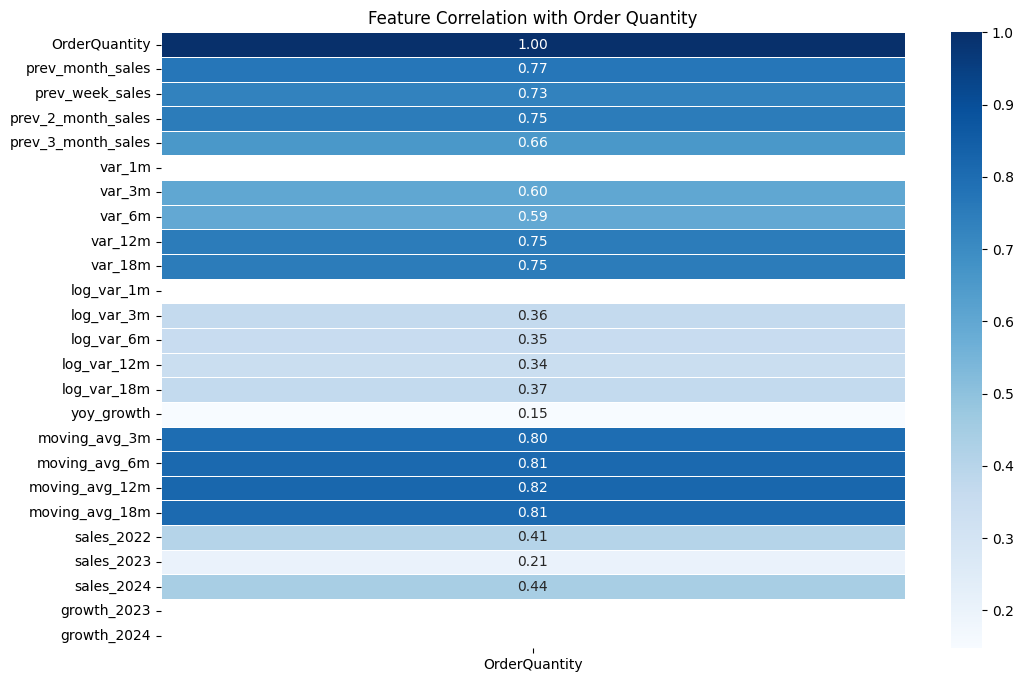

In [8]:
ph.feature_importance(custom_code_df)

In [9]:
from scipy import stats

# Define a function to compute z-scores within each product group
def compute_zscore(group, threshold=3):
    # Only compute z-score if there are at least 2 data points in the group
    if len(group) >= 2:
        group['z_score'] = np.abs(stats.zscore(group['OrderQuantity']))
    else:
        group['z_score'] = 0  # or np.nan if preferred
    return group

# Group by "ProductNumber" and compute z-scores for "OrderQuantity" within each group
df_grouped = custom_code_df.groupby('ProductNumber').apply(compute_zscore)

# Define your threshold for what constitutes an "unusually high" order
z_threshold = 3

# Filter for outliers (orders with a z_score greater than the threshold)
df_outliers = df_grouped[df_grouped['z_score'] > z_threshold]

# Display the results
print("Unusually high order quantities (per ProductNumber):")
print(df_outliers[['ProductNumber', 'OrderQuantity', 'z_score']])

print(f'Dropping: \n{df_outliers.count()}')
# Keep only rows where the z-score is within the acceptable range
df_cleaned = df_grouped[df_grouped['z_score'] <= z_threshold].drop(columns=['z_score'])

# Reset index for clarity
df_cleaned.reset_index(drop=True, inplace=True)

custom_code_df = df_cleaned


Unusually high order quantities (per ProductNumber):
                    ProductNumber  OrderQuantity   z_score
ProductNumber                                             
ALB-026-0004Z 2580  ALB-026-0004Z        1272371  5.941349
              6162  ALB-026-0004Z        1240531  5.779581
ALB-026-0005Z 903   ALB-026-0005Z        1339292  3.845622
              2255  ALB-026-0005Z        1252643  3.559331
              2474  ALB-026-0005Z        1530903  4.478712
...                           ...            ...       ...
ALB-026-0137Z 16    ALB-026-0137Z        1104822  4.185388
              3034  ALB-026-0137Z        1221670  4.682559
              4561  ALB-026-0137Z         983103  3.667492
              5599  ALB-026-0137Z         936409  3.468816
              6020  ALB-026-0137Z        1010862  3.785602

[220 rows x 3 columns]
Dropping: 
ProductNumber         220
order_year            220
order_month           220
order_week            220
order_weekday         220
is_weekend     

C:\Users\44777\AppData\Local\Temp\ipykernel_30000\1363007664.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = custom_code_df.groupby('ProductNumber').apply(compute_zscore)


In [10]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
df = custom_code_df

features = ['ProductNumber', 'order_month',
            'prev_month_sales', 'prev_week_sales', 'prev_2_month_sales', 'prev_3_month_sales',
            'moving_avg_3m', 'moving_avg_6m', 'moving_avg_12m', 'moving_avg_18m',
            'var_3m', 'var_6m', 'var_12m', 'var_18m',
            'log_var_3m', 'log_var_6m', 'log_var_12m', 'log_var_18m',
            'yoy_growth', 'sales_2023', 'sales_2024'
            ]
target = 'OrderQuantity'

X = df[features]
y = df[target]

# one-hot encoding for categorical features
categorical_features = ['ProductNumber']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# preprocessor (keeps numerical features as is)
preprocessor = ColumnTransformer(
    transformers=[
        # one-hot encode categorical features
        ('cat', encoder, categorical_features)
    ], remainder='passthrough'
)

# transform the features
X_transformed = preprocessor.fit_transform(X)


In [11]:
# all products order quants for defined customer list (2022-2025)
X_train, X_val, y_train, y_val = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [12]:
customer_total = df.copy()

# define features and target
features = ['ProductNumber', 'order_month', 'order_week', 'order_weekday',
            'prev_month_sales', 'prev_week_sales', 'prev_2_month_sales', 'prev_3_month_sales',
            'moving_avg_3m', 'moving_avg_6m', 'moving_avg_12m', 'moving_avg_18m',
            'var_3m', 'var_6m', 'var_12m', 'var_18m',
            'log_var_3m', 'log_var_6m', 'log_var_12m', 'log_var_18m',
            'yoy_growth', 'sales_2023', 'sales_2024'
           ]
target = 'OrderQuantity'

# filter the top products
total_X = customer_total[features]  # Features from top products
total_y = customer_total[target]    # Target variable

# define categorical and numeric features
categorical_features = ['ProductNumber']
numeric_features = list(set(features) - set(categorical_features))  # All other features are numeric

# Define transformations
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# ColumnTransformer to apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_features),   # One-hot encode categorical features
        ('num', scaler, numeric_features)        # Standardize numeric features
    ]
)

# Train-test split
total_X_train, total_X_val, total_y_train, total_y_val = train_test_split(total_X, total_y, test_size=0.2, random_state=42)

# Transform the features
total_X_train_transformed = preprocessor.fit_transform(total_X_train)
total_X_val_transformed = preprocessor.transform(total_X_val)

# Output the shape
print(f"Train Shape: {total_X_train_transformed.shape}, Validation Shape: {total_X_val_transformed.shape}")
print("Feature processing for top products completed successfully!")

customer_total.head()


Train Shape: (4871, 84), Validation Shape: (1218, 84)
Feature processing for top products completed successfully!


,ProductNumber,order_year,order_month,order_week,order_weekday,is_weekend,OrderDate,Customer_Num,OrderQuantity,prev_month_sales,...,moving_avg_3m,moving_avg_6m,moving_avg_12m,moving_avg_18m,sales_2022,sales_2023,sales_2024,growth_2023,growth_2024,PhysicalInv
0,ALB-026-0004Z,2025,2,11,0,0,2024-12-03,65.0,16994,111145.289385,...,15526.805860,13724.694737,8663.913107,17685.125044,176,0,0,-100.0,-100.0,92
1,ALB-026-0004Z,2022,3,11,3,0,2022-02-13,69.0,4897,18688.659124,...,41088.516630,7932.651628,11849.746367,5928.251908,17460,352,0,-100.0,-100.0,262
2,ALB-026-0004Z,2022,5,14,1,0,2022-03-25,63.0,51362,155508.955856,...,165507.093091,88257.123631,132452.771914,38658.170199,167418,336,0,-100.0,-100.0,333
3,ALB-026-0004Z,2024,10,47,5,1,2024-11-21,236.0,109811,115354.619471,...,101454.057653,77050.778052,114503.983452,106594.709404,618,92,122800,-100.0,-100.0,358
4,ALB-026-0004Z,2024,10,27,4,0,2024-01-20,192.0,44628,51552.387076,...,35549.011055,119828.601248,133389.241849,26274.941773,0,297,46361,-100.0,-100.0,74389


In [13]:
# the top 10 (or change) products by total actual order quantity
top_products = df.groupby('ProductNumber')['OrderQuantity'].sum().nlargest(5)

# extract top product code rows from the original df
top_prods_df = df[df['ProductNumber'].isin(top_products.index)]

# Extract top product numbers
top_product_numbers = top_products.index.tolist()  # List of top product numbers

top_prods_df.head()

unique_order_years = custom_code_df['order_year'].unique()
print(unique_order_years)

[2025 2022 2024 2023 2021 2020]


In [14]:
print("Number of samples in top_prods_df:", len(top_prods_df))

Number of samples in top_prods_df: 512


In [15]:
# define features and target
features = ['ProductNumber', 'order_month', 
            'prev_month_sales', 'prev_week_sales', 'prev_2_month_sales', 'prev_3_month_sales',
            'moving_avg_3m', 'moving_avg_6m', 'moving_avg_12m', 'moving_avg_18m',
            'var_3m', 'var_6m', 'var_12m', 'var_18m',
            'log_var_3m', 'log_var_6m', 'log_var_12m', 'log_var_18m',
            'yoy_growth', 'sales_2023', 'sales_2024'
           ]
target = 'OrderQuantity'

# filter the top products
tp_X = top_prods_df[features]  # Features from top products
tp_y = top_prods_df[target]    # Target variable

# define categorical and numeric features
categorical_features = ['ProductNumber']
numeric_features = list(set(features) - set(categorical_features))  # All other features are numeric

# Define transformations
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

# ColumnTransformer to apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', encoder, categorical_features),   # One-hot encode categorical features
        ('num', scaler, numeric_features)        # Standardize numeric features
    ]
)

# Train-test split
tp_X_train, tp_X_val, tp_y_train, tp_y_val = train_test_split(tp_X, tp_y, test_size=0.2, random_state=42)

# Transform the features
tp_X_train_transformed = preprocessor.fit_transform(tp_X_train)
tp_X_val_transformed = preprocessor.transform(tp_X_val)

# Output the shape
print(f"Train Shape: {tp_X_train_transformed.shape}, Validation Shape: {tp_X_val_transformed.shape}")
print("Feature processing for top products completed successfully!")


Train Shape: (409, 25), Validation Shape: (103, 25)
Feature processing for top products completed successfully!


In [16]:
from sklearn.ensemble import RandomForestRegressor
from model_utils import *

d:\SCM---ML-Visualisation\tf_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
rf_params = {
    'criterion': 'squared_error',
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'n_estimators': 200,
    'random_state': 42
}


In [18]:
print(rf_params)

{'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'random_state': 42}


In [19]:
rf = RandomForestRegressor(**rf_params)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_val_scaled)

In [20]:
print('---------------------- TRAINING PERFORMANCE ----------------------')
evaluate_model(rf, X_train_scaled, y_train)
print('--------------------------------------------')

print('---------------------- TEST PERFORMANCE ----------------------')
evaluate_model(rf, X_val_scaled, y_val)
print('--------------------------------------------')

---------------------- TRAINING PERFORMANCE ----------------------
Mean Absolute Error (MAE): 17675.8839
Mean Squared Error (MSE): 1101416980.6943
Root Mean Squared Error (RMSE): 33187.6028
R-squared (R²): 0.9322
--------------------------------------------
---------------------- TEST PERFORMANCE ----------------------
Mean Absolute Error (MAE): 40893.9330
Mean Squared Error (MSE): 5171768670.9407
Root Mean Squared Error (RMSE): 71915.0101
R-squared (R²): 0.6167
--------------------------------------------


In [21]:
# train the model with scaled features (Random Forest Regressor) - TOTAL CUSTOM PRODUCTS IMPLEMENTATION
# total_rf = RandomForestRegressor()
# total_rf_params = find_best_hyperparameters(total_rf, param_grids(total_rf.__class__.__name__), total_X_train_transformed, total_y_train)

In [22]:
# total_rf = RandomForestRegressor(**total_rf_params)
# total_rf.fit(total_X_train_transformed, total_y_train)
# total_y_pred_rf = total_rf.predict(total_X_val_transformed)

In [23]:
# print('---------------------- TRAINING PERFORMANCE ----------------------')
# evaluate_model(total_rf, total_X_train_transformed, total_y_train)
# print('--------------------------------------------')

# print('---------------------- TEST PERFORMANCE ----------------------')
# evaluate_model(total_rf, total_X_val_transformed, total_y_val)
# print('--------------------------------------------')

[68975.32181150795, 187928.03353174598, 20758.507956349196, 79506.47808333332, 24108.232049603183, 20720.00395436508, 439895.61362500006, 26394.150763888872, 28390.578384920635, 42310.69112716452, 15020.439720238093, 228307.31725396827, 112753.84874801585, 42364.64475000001, 76356.7858293651, 10494.802906746034, 40401.04857539685, 167239.43485119054, 87598.02432142857, 18689.53824603175, 247006.30272619065, 40927.785898809496, 71622.8195138889, 73125.41066468254, 60288.704263888874, 55787.637613095256, 87631.12793650792, 158745.6596646825, 346009.3366369048, 284656.5652678571, 45527.61952777779, 34571.74782738097, 67060.79122023808, 28892.164174603186, 91550.1879794372, 95956.93701388886, 24478.296420634906, 38667.45239664501, 55690.68373214283, 83065.64250595238, 158743.13192261913, 63563.66194047618, 36834.708, 108355.9689801587, 216809.91080357146, 36847.86798809524, 23435.286509920625, 90865.46112301586, 125549.96426190478, 370307.4662380952, 17743.584101190474, 9826.752976190479, 

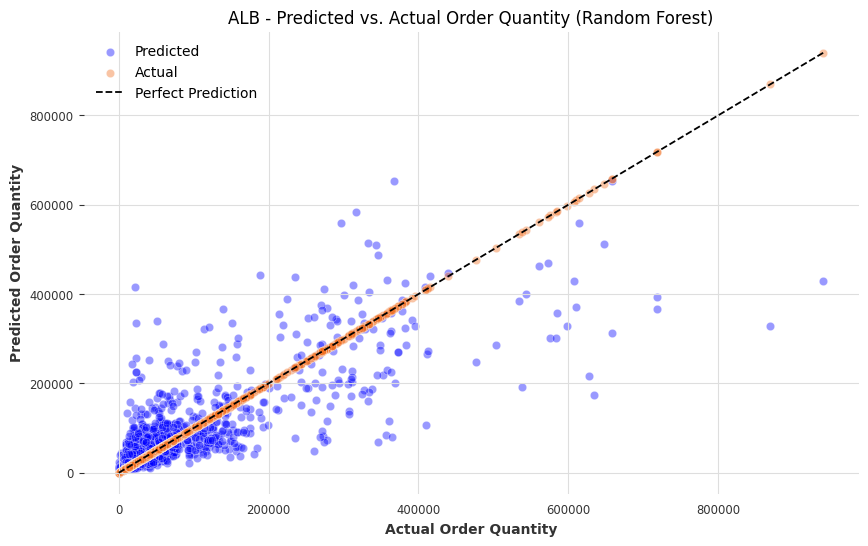

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

print(y_pred_rf.tolist())

plt.figure(figsize=(10, 6))

# scatter plot, actual vs predicted values
sns.scatterplot(x=y_val, y=y_pred_rf, alpha=0.4, color='blue', label='Predicted')  # Predicted values in blue

# actual values in red
sns.scatterplot(x=y_val, y=y_val, alpha=0.4, color='#f26d1d', label='Actual')

# reference line for perfect prediction
plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], '--', color='black', label="Perfect Prediction")

plt.xlabel("Actual Order Quantity")
plt.ylabel("Predicted Order Quantity")
plt.title(f"{custom_ref} - Predicted vs. Actual Order Quantity (Random Forest)")
plt.legend()

plt.show()

C:\Users\44777\AppData\Local\Temp\ipykernel_30000\1606837329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_prods_df['OrderDate'] = pd.to_datetime(top_prods_df[['order_year', 'order_month']].astype(str).agg('-'.join, axis=1))


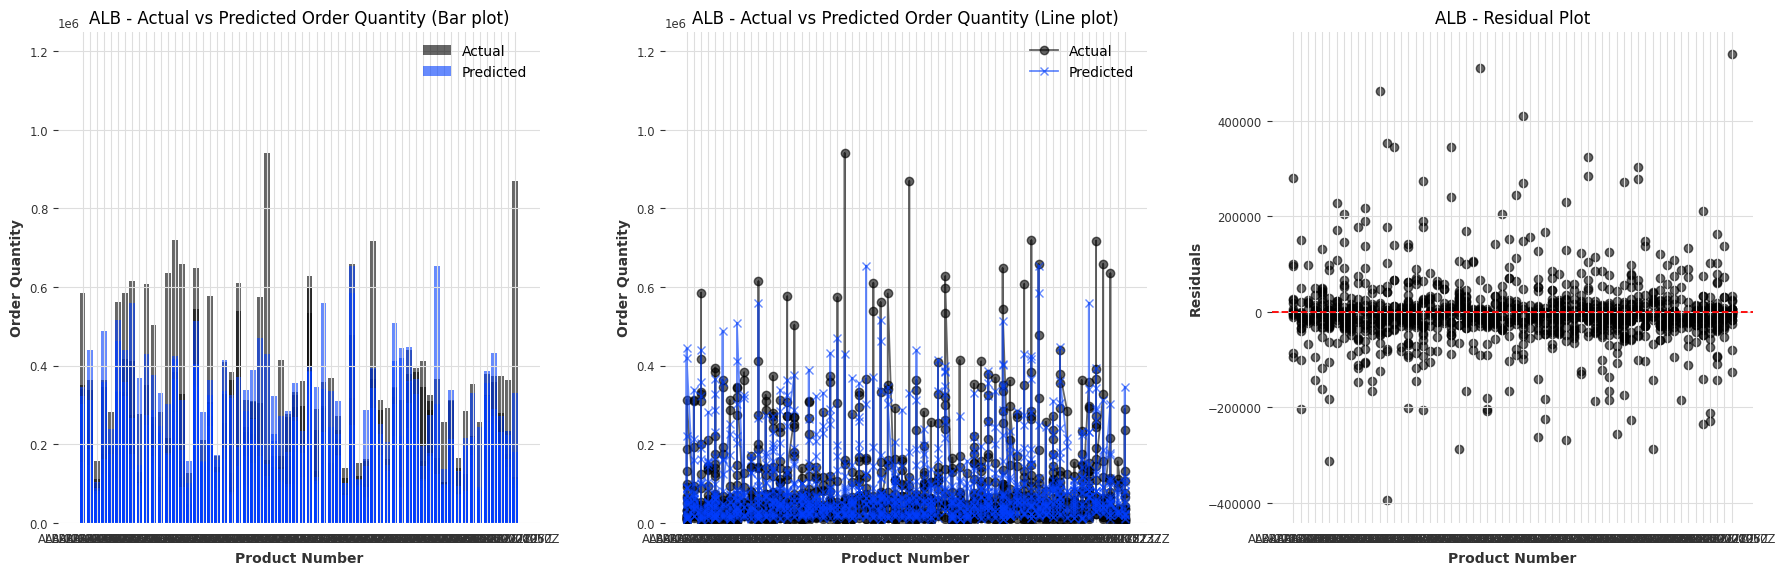

In [25]:
# Convert order year and month to datetime format
top_prods_df['OrderDate'] = pd.to_datetime(top_prods_df[['order_year', 'order_month']].astype(str).agg('-'.join, axis=1))

# Sort by OrderDate to maintain time order
top_prods_df = top_prods_df.sort_values(by='OrderDate')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Bar plot, actual and predicted values over time
axes[0].bar(df.loc[y_val.index, 'ProductNumber'], y_val, label='Actual', alpha=0.6)
axes[0].bar(df.loc[y_val.index, 'ProductNumber'], y_pred_rf, label='Predicted', alpha=0.6)
axes[0].set_xlabel('Product Number')
axes[0].set_ylabel('Order Quantity')
axes[0].set_title(f'{custom_ref} - Actual vs Predicted Order Quantity (Bar plot)')
axes[0].set_ylim(0, 1250000)
axes[0].legend()

# Line plot, actual and predicted values
sorted_indices = df.loc[y_val.index, 'ProductNumber'].argsort()
sorted_products = df.loc[y_val.index, 'ProductNumber'].iloc[sorted_indices]
sorted_actual = y_val.iloc[sorted_indices]
sorted_predicted = y_pred_rf[sorted_indices]

axes[1].plot(sorted_products, sorted_actual, label='Actual', alpha=0.6, marker='o')
axes[1].plot(sorted_products, sorted_predicted, label='Predicted', alpha=0.6, marker='x')
axes[1].set_xlabel('Product Number')
axes[1].set_ylabel('Order Quantity')
axes[1].set_title(f'{custom_ref} - Actual vs Predicted Order Quantity (Line plot)')
axes[1].set_ylim(0, 1250000)
axes[1].legend()

# Residual plot
residuals = y_val - y_pred_rf
axes[2].scatter(df.loc[y_val.index, 'ProductNumber'], residuals, alpha=0.6)
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Product Number')
axes[2].set_ylabel('Residuals')
axes[2].set_title(f'{custom_ref} - Residual Plot')

plt.tight_layout()
plt.show()


In [26]:
# Convert order year and month to datetime format
customer_total['OrderDate'] = pd.to_datetime(customer_total[['order_year', 'order_month']].astype(str).agg('-'.join, axis=1))

# Sort by OrderDate to maintain time order
customer_total = customer_total.sort_values(by='OrderDate')

In [27]:
# total_y_val.type

In [28]:
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# # Bar plot, actual and predicted values over time
# axes[0].bar(customer_total.loc[total_y_val.index, 'OrderDate'], total_y_val, label='Actual', alpha=0.6)
# axes[0].bar(customer_total.loc[total_y_val.index, 'OrderDate'], total_y_pred_rf, label='Predicted', alpha=0.6)
# axes[0].set_xlabel('Order Date')
# axes[0].set_ylabel('Order Quantity')
# axes[0].set_title(f'{custom_ref} - Actual vs Predicted Order Quantity Over Time')
# axes[0].set_ylim(0, 3000000)
# axes[0].legend()
# axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for readability

# # Line plot, actual and predicted values over time
# sorted_indices = top_prods_df.loc[tp_y_val.index, 'OrderDate'].argsort()
# sorted_dates = top_prods_df.loc[tp_y_val.index, 'OrderDate'].iloc[sorted_indices]
# sorted_actual = total_y_val.iloc[sorted_indices]
# sorted_predicted = total_y_pred_rf[sorted_indices]

# axes[1].plot(sorted_dates, sorted_actual, label='Actual', alpha=0.6, marker='o', linestyle='-')
# axes[1].plot(sorted_dates, sorted_predicted, label='Predicted', alpha=0.6, marker='x', linestyle='--')
# axes[1].set_xlabel('Order Date')
# axes[1].set_ylabel('Order Quantity')
# axes[1].set_title(f'{custom_ref} - Actual vs Predicted Order Quantity Over Time')
# axes[1].set_ylim(0, 3000000)
# axes[1].legend()
# axes[1].tick_params(axis='x', rotation=45)

# # Residual plot over time
# residuals = total_y_val - total_y_pred_rf
# axes[2].scatter(customer_total.loc[total_y_val.index, 'OrderDate'], residuals, alpha=0.6)
# axes[2].axhline(y=0, color='r', linestyle='--')
# axes[2].set_xlabel('Order Date')
# axes[2].set_ylabel('Residuals')
# axes[2].set_title(f'{custom_ref} - Residual Plot Over Time')
# axes[2].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

In [29]:
# # to see dataframe structure
# customer_total.head()


In [30]:
# # to see prediction nparray structure
# total_y_pred_rf

In [31]:
# # Group data by OrderDate and sum the relevant numerical columns
# customer_total = top_prods_df.groupby('OrderDate').sum(numeric_only=True).reset_index()

In [32]:
customer_total.head()

,ProductNumber,order_year,order_month,order_week,order_weekday,is_weekend,OrderDate,Customer_Num,OrderQuantity,prev_month_sales,...,moving_avg_3m,moving_avg_6m,moving_avg_12m,moving_avg_18m,sales_2022,sales_2023,sales_2024,growth_2023,growth_2024,PhysicalInv
5194,ALB-026-0092Z,2020,1,51,0,0,2020-01-01,191.0,600753,362779.293367,...,559793.052515,519531.058962,705173.461412,1.121972e+06,0,102,259,-100.0,-100.0,453
3635,ALB-026-0060Z,2020,1,51,1,0,2020-01-01,111.0,11901,52906.037557,...,12939.096542,5311.655261,36361.315302,3.107910e+03,79,144,0,-100.0,-100.0,20758
978,ALB-026-0017Y,2020,1,8,4,0,2020-01-01,276.0,10246,15343.092788,...,18301.907374,13479.781058,43806.046295,2.294815e+04,102,0,767,-100.0,-100.0,3668
2188,ALB-026-0030Z,2020,1,27,2,0,2020-01-01,13.0,19798,109234.835623,...,13718.086200,13311.174566,14748.718379,7.390520e+03,0,99,70,-100.0,-100.0,100
4348,ALB-026-0074Z,2020,1,7,4,0,2020-01-01,101.0,4117,110178.479670,...,14095.034764,6440.106448,14971.848675,6.672993e+03,0,0,13,-100.0,-100.0,207


In [33]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # Subplots
# fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
# fig.subplots_adjust(hspace=0.4, wspace=0.3)  # Adjust layout for better spacing

# # Bar plot: Actual vs. Predicted Order Quantity
# axes[0, 0].bar(customer_total.loc[total_y_val.index, 'OrderDate'], total_y_val, label='Actual', alpha=0.6)
# axes[0, 0].bar(customer_total.loc[total_y_val.index, 'OrderDate'], total_y_pred_rf, label='Predicted', alpha=0.6)
# axes[0, 0].set_xlabel('Order Date')
# axes[0, 0].set_ylabel('Order Quantity')
# axes[0, 0].set_title(f'{custom_ref} Total Products - Actual vs Predicted (Bar Plot)')
# axes[0, 0].set_ylim(0, 500_000)
# axes[0, 0].legend()
# axes[0, 0].tick_params(axis='x', rotation=45)

# # Residual Plot
# residuals = total_y_val - total_y_pred_rf
# axes[0, 1].scatter(customer_total.loc[total_y_val.index, 'OrderDate'], residuals, alpha=0.6)
# axes[0, 1].axhline(y=0, color='r', linestyle='--')
# axes[0, 1].set_xlabel('Order Date')
# axes[0, 1].set_ylabel('Residuals')
# axes[0, 1].set_title(f'{custom_ref} Total Products - Residual Plot')
# axes[0, 1].tick_params(axis='x', rotation=45)

# # Pie Chart: Order Quantity per Month (2024)
# order_2024 = customer_total[customer_total['order_year'] == 2024].groupby('order_month')['OrderQuantity'].sum()
# axes[0, 2].pie(order_2024, labels=order_2024.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
# axes[0, 2].set_title(f'{custom_ref} Order Quantity Distribution (2024)')

# # Line Plots: Yearly Trends
# for i, year in enumerate([2022, 2023, 2024]):  
#     yearly_df = customer_total[customer_total['order_year'] == year]

#     if yearly_df.empty:
#         continue  # skip if no data for that year

#     # Aggregate OrderQuantity per month
#     monthly_actual = yearly_df.groupby('order_month')['OrderQuantity'].sum()

#     # Convert total_y_pred_rf to Pandas Series with index from customer_total
#     pred_series = pd.Series(total_y_pred_rf, index=total_y_val.index)

#     # Group predictions by month
#     monthly_predicted = pred_series.groupby(customer_total.loc[total_y_val.index, 'order_month']).sum()

#     # Sort for proper plotting
#     monthly_actual = monthly_actual.sort_index()
#     monthly_predicted = monthly_predicted.reindex(monthly_actual.index)  # Ensure same months

#     # Plot actual and predicted values for the year
#     axes[1, i].plot(monthly_actual.index, monthly_actual, label='Actual', alpha=0.6, marker='o', linestyle='-')
#     axes[1, i].plot(monthly_predicted.index, monthly_predicted, label='Predicted', alpha=0.6, marker='x', linestyle='--')

#     axes[1, i].set_xlabel('Month')
#     axes[1, i].set_ylabel('Order Quantity')
#     axes[1, i].set_title(f'{custom_ref} {year} Total Products - Actual vs Predicted')
#     axes[1, i].set_ylim(0, max(monthly_actual.max(), monthly_predicted.max()) * 1.1)  # Scale Y axis
#     axes[1, i].legend()
#     axes[1, i].tick_params(axis='x', rotation=45)

# # Adjust layout for better spacing between subplots
# plt.tight_layout()
# plt.show()


In [34]:
has_orders_2022 = not customer_total[customer_total['order_year'] == 2022].empty
print(f"Orders in 2022 exist: {has_orders_2022}")


Orders in 2022 exist: True


In [35]:
customer_total.head(10)

,ProductNumber,order_year,order_month,order_week,order_weekday,is_weekend,OrderDate,Customer_Num,OrderQuantity,prev_month_sales,...,moving_avg_3m,moving_avg_6m,moving_avg_12m,moving_avg_18m,sales_2022,sales_2023,sales_2024,growth_2023,growth_2024,PhysicalInv
5194,ALB-026-0092Z,2020,1,51,0,0,2020-01-01,191.0,600753,362779.293367,...,559793.052515,519531.058962,705173.461412,1.121972e+06,0,102,259,-100.0,-100.0,453
3635,ALB-026-0060Z,2020,1,51,1,0,2020-01-01,111.0,11901,52906.037557,...,12939.096542,5311.655261,36361.315302,3.107910e+03,79,144,0,-100.0,-100.0,20758
978,ALB-026-0017Y,2020,1,8,4,0,2020-01-01,276.0,10246,15343.092788,...,18301.907374,13479.781058,43806.046295,2.294815e+04,102,0,767,-100.0,-100.0,3668
2188,ALB-026-0030Z,2020,1,27,2,0,2020-01-01,13.0,19798,109234.835623,...,13718.086200,13311.174566,14748.718379,7.390520e+03,0,99,70,-100.0,-100.0,100
4348,ALB-026-0074Z,2020,1,7,4,0,2020-01-01,101.0,4117,110178.479670,...,14095.034764,6440.106448,14971.848675,6.672993e+03,0,0,13,-100.0,-100.0,207
5450,ALB-026-0106Z,2020,1,2,3,0,2020-01-01,8.0,6154,7310.990527,...,7062.798250,4491.139844,7120.016309,1.013294e+04,21715,13796,0,-100.0,-100.0,219
4670,ALB-026-0085Z,2020,1,51,4,0,2020-01-01,109.0,24034,108306.287100,...,6058.523492,8487.957229,7467.841877,4.764746e+03,0,0,0,-100.0,-100.0,356
916,ALB-026-0016Y,2020,1,3,2,0,2020-01-01,12.0,8989,40713.011691,...,7658.985075,13296.022569,8147.262727,7.851647e+03,17230,0,27,-100.0,-100.0,54
6019,ALB-026-0137Z,2020,2,7,2,0,2020-02-01,8.0,3563,107116.312936,...,4978.792816,14017.696425,4288.077056,9.207151e+03,0,0,0,-100.0,-100.0,365
3360,ALB-026-0056Z,2020,2,51,3,0,2020-02-01,188.0,5419,36421.505469,...,15359.206898,7114.883578,12309.305830,9.011920e+03,0,42,0,-100.0,-100.0,24182


In [36]:
# from powerbiclient import QuickVisualize, get_dataset_config, Report
# from powerbiclient.authentication import InteractiveLoginAuthentication, DeviceCodeLoginAuthentication
# import pandas as pd

# prod_sales = pd.read_csv(
#     '/Users/mwilko777/Desktop/Project/Software Artifact/datasets/stock_forecasting/final/product_sales.csv')

# # use DeviceCodeLoginAuthentication if want to sign in each time, else InteractiveLoginAuthentication
# auth = InteractiveLoginAuthentication()
# print("Authentication successful.")


# def visual():
#     dataset_config = get_dataset_config(prod_sales)
#     return QuickVisualize(dataset_config, auth)

# visual()

In [37]:
customer_total.head()

,ProductNumber,order_year,order_month,order_week,order_weekday,is_weekend,OrderDate,Customer_Num,OrderQuantity,prev_month_sales,...,moving_avg_3m,moving_avg_6m,moving_avg_12m,moving_avg_18m,sales_2022,sales_2023,sales_2024,growth_2023,growth_2024,PhysicalInv
5194,ALB-026-0092Z,2020,1,51,0,0,2020-01-01,191.0,600753,362779.293367,...,559793.052515,519531.058962,705173.461412,1.121972e+06,0,102,259,-100.0,-100.0,453
3635,ALB-026-0060Z,2020,1,51,1,0,2020-01-01,111.0,11901,52906.037557,...,12939.096542,5311.655261,36361.315302,3.107910e+03,79,144,0,-100.0,-100.0,20758
978,ALB-026-0017Y,2020,1,8,4,0,2020-01-01,276.0,10246,15343.092788,...,18301.907374,13479.781058,43806.046295,2.294815e+04,102,0,767,-100.0,-100.0,3668
2188,ALB-026-0030Z,2020,1,27,2,0,2020-01-01,13.0,19798,109234.835623,...,13718.086200,13311.174566,14748.718379,7.390520e+03,0,99,70,-100.0,-100.0,100
4348,ALB-026-0074Z,2020,1,7,4,0,2020-01-01,101.0,4117,110178.479670,...,14095.034764,6440.106448,14971.848675,6.672993e+03,0,0,13,-100.0,-100.0,207


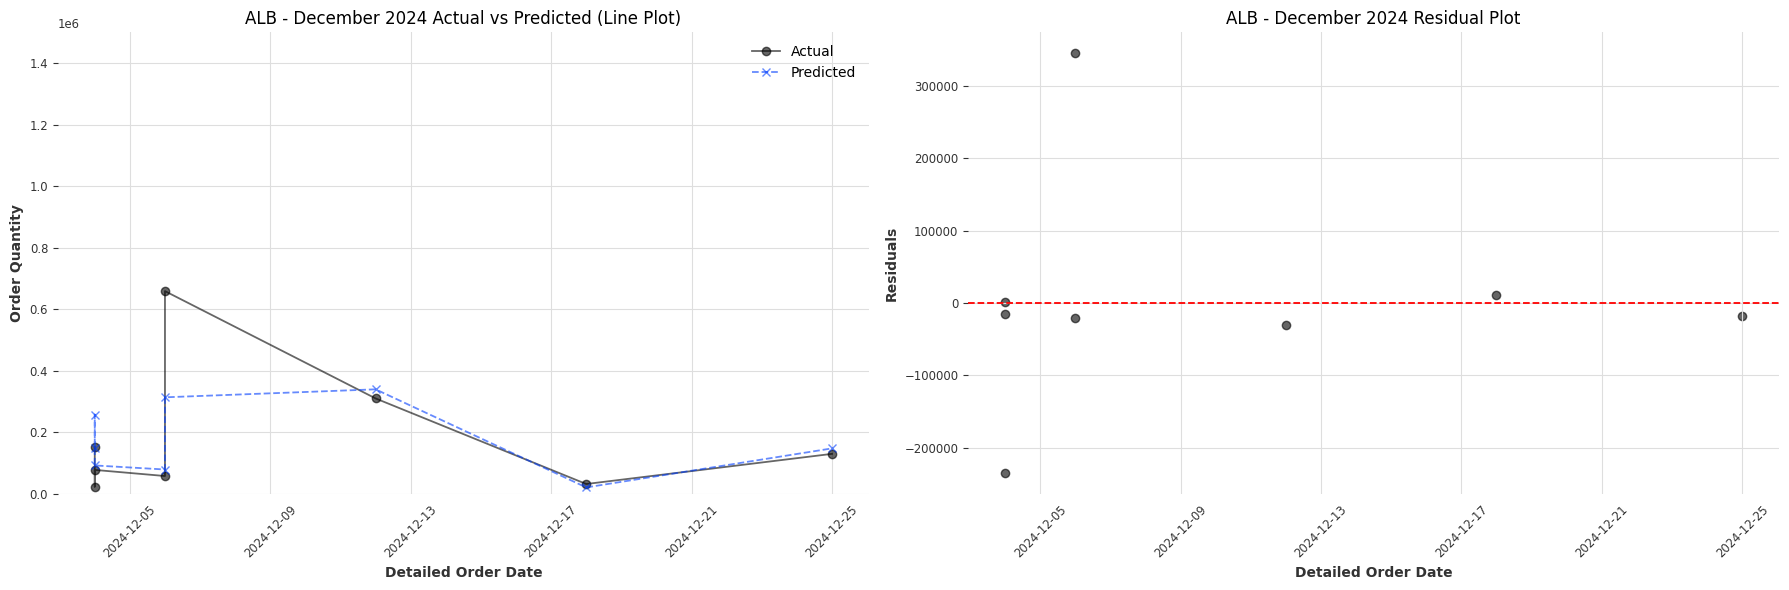

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create a DetailedOrderDate column using week and weekday information.
# Adjust the format as needed based on your data.
customer_total['DetailedOrderDate'] = pd.to_datetime(
    customer_total['order_year'].astype(str) +
    customer_total['order_week'].astype(str).str.zfill(2) +
    customer_total['order_weekday'].astype(str),
    format='%Y%W%w'
)

# Filter the data for December 2024 using DetailedOrderDate
dec_2024_data = customer_total[
    (customer_total['DetailedOrderDate'].dt.year == 2024) &
    (customer_total['DetailedOrderDate'].dt.month == 12)
]

# Use only the common indices between dec_2024_data and y_val
common_index = dec_2024_data.index.intersection(y_val.index)
dec_2024_actual = y_val.loc[common_index]
# Convert y_pred_rf to a Series for indexing (using the same index as y_val)
y_pred_rf_series = pd.Series(y_pred_rf, index=y_val.index)
dec_2024_predicted = y_pred_rf_series.loc[common_index]

# --- Incorporate your provided sorting snippet, adapted for December 2024 data ---
# Here we sort by DetailedOrderDate from dec_2024_data for the common indices.
sorted_indices = dec_2024_data.loc[common_index, 'DetailedOrderDate'].argsort()
sorted_dates = dec_2024_data.loc[common_index, 'DetailedOrderDate'].iloc[sorted_indices]
sorted_actual = dec_2024_actual.iloc[sorted_indices]
sorted_predicted = dec_2024_predicted.iloc[sorted_indices]
# --- End of sorting snippet ---

# Create subplots (1 row, 2 columns: one for line plot, one for residual plot)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Line Plot: Actual vs. Predicted Order Quantity using DetailedOrderDate
axes[0].plot(sorted_dates, sorted_actual, label='Actual', alpha=0.6, marker='o', linestyle='-')
axes[0].plot(sorted_dates, sorted_predicted, label='Predicted', alpha=0.6, marker='x', linestyle='--')
axes[0].set_xlabel('Detailed Order Date')
axes[0].set_ylabel('Order Quantity')
axes[0].set_title(f'{custom_ref} - December 2024 Actual vs Predicted (Line Plot)')
axes[0].set_ylim(0, 1_500_000)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Residual Plot for December 2024
residuals_dec_2024 = sorted_actual - sorted_predicted
axes[1].scatter(sorted_dates, residuals_dec_2024, alpha=0.6)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Detailed Order Date')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'{custom_ref} - December 2024 Residual Plot')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [39]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le  # Store encoder for inverse transformation if needed

# Handle missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)


C:\Users\44777\AppData\Local\Temp\ipykernel_30000\4258343104.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


In [40]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Split Data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
metrics = {}

### Random Forest ###
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print('\n' + '='*30 + ' RANDOM FOREST ' + '='*30)
evaluate_model(rf_model, X_train, y_train)
test_metrics = evaluate_model(rf_model, X_val, y_val)
metrics['Random Forest'] = test_metrics

### XGBoost ###
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
param_grid = {
    'n_estimators': [100, 300],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
}
grid_xgb = GridSearchCV(xgb_model, param_grid, cv=3, 
                      scoring='neg_mean_absolute_error', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print('\n' + '='*30 + ' XGBOOST ' + '='*30)
evaluate_model(best_xgb, X_train, y_train)
test_metrics = evaluate_model(best_xgb, X_val, y_val)
metrics['XGBoost'] = test_metrics

### Neural Network ###
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

mlp = MLPRegressor(hidden_layer_sizes=(128, 64), learning_rate_init=0.01,
                 max_iter=1000, early_stopping=True, random_state=42)
mlp.fit(X_train_scaled, y_train)

print('\n' + '='*30 + ' NEURAL NETWORK ' + '='*30)
evaluate_model(mlp, X_train_scaled, y_train)
test_metrics = evaluate_model(mlp, X_val_scaled, y_val)
metrics['Neural Network'] = test_metrics

# Convert metrics to DataFrame
metrics_df = pd.DataFrame({k: v for k, v in metrics.items()}).T
# metrics_df = metrics_df[['MAE', 'MSE', 'RMSE', 'R²']]
print('\nFINAL METRICS SUMMARY:')
print(metrics_df)


============================== RANDOM FOREST ==============================
Mean Absolute Error (MAE): 15685.6127
Mean Squared Error (MSE): 794548329.4623
Root Mean Squared Error (RMSE): 28187.7337
R-squared (R²): 0.9511
Mean Absolute Error (MAE): 41412.9458
Mean Squared Error (MSE): 5182729891.9773
Root Mean Squared Error (RMSE): 71991.1793
R-squared (R²): 0.6159

============================== XGBOOST ==============================
Mean Absolute Error (MAE): 34723.4805
Mean Squared Error (MSE): 3192764160.0000
Root Mean Squared Error (RMSE): 56504.5499
R-squared (R²): 0.8036
Mean Absolute Error (MAE): 40872.9180
Mean Squared Error (MSE): 5060861440.0000
Root Mean Squared Error (RMSE): 71139.7318
R-squared (R²): 0.6249

============================== NEURAL NETWORK ==============================
Mean Absolute Error (MAE): 42643.0527
Mean Squared Error (MSE): 5428066554.7541
Root Mean Squared Error (RMSE): 73675.4135
R-squared (R²): 0.6661
Mean Absolute Error (MAE): 42234.6012
Mean Sq

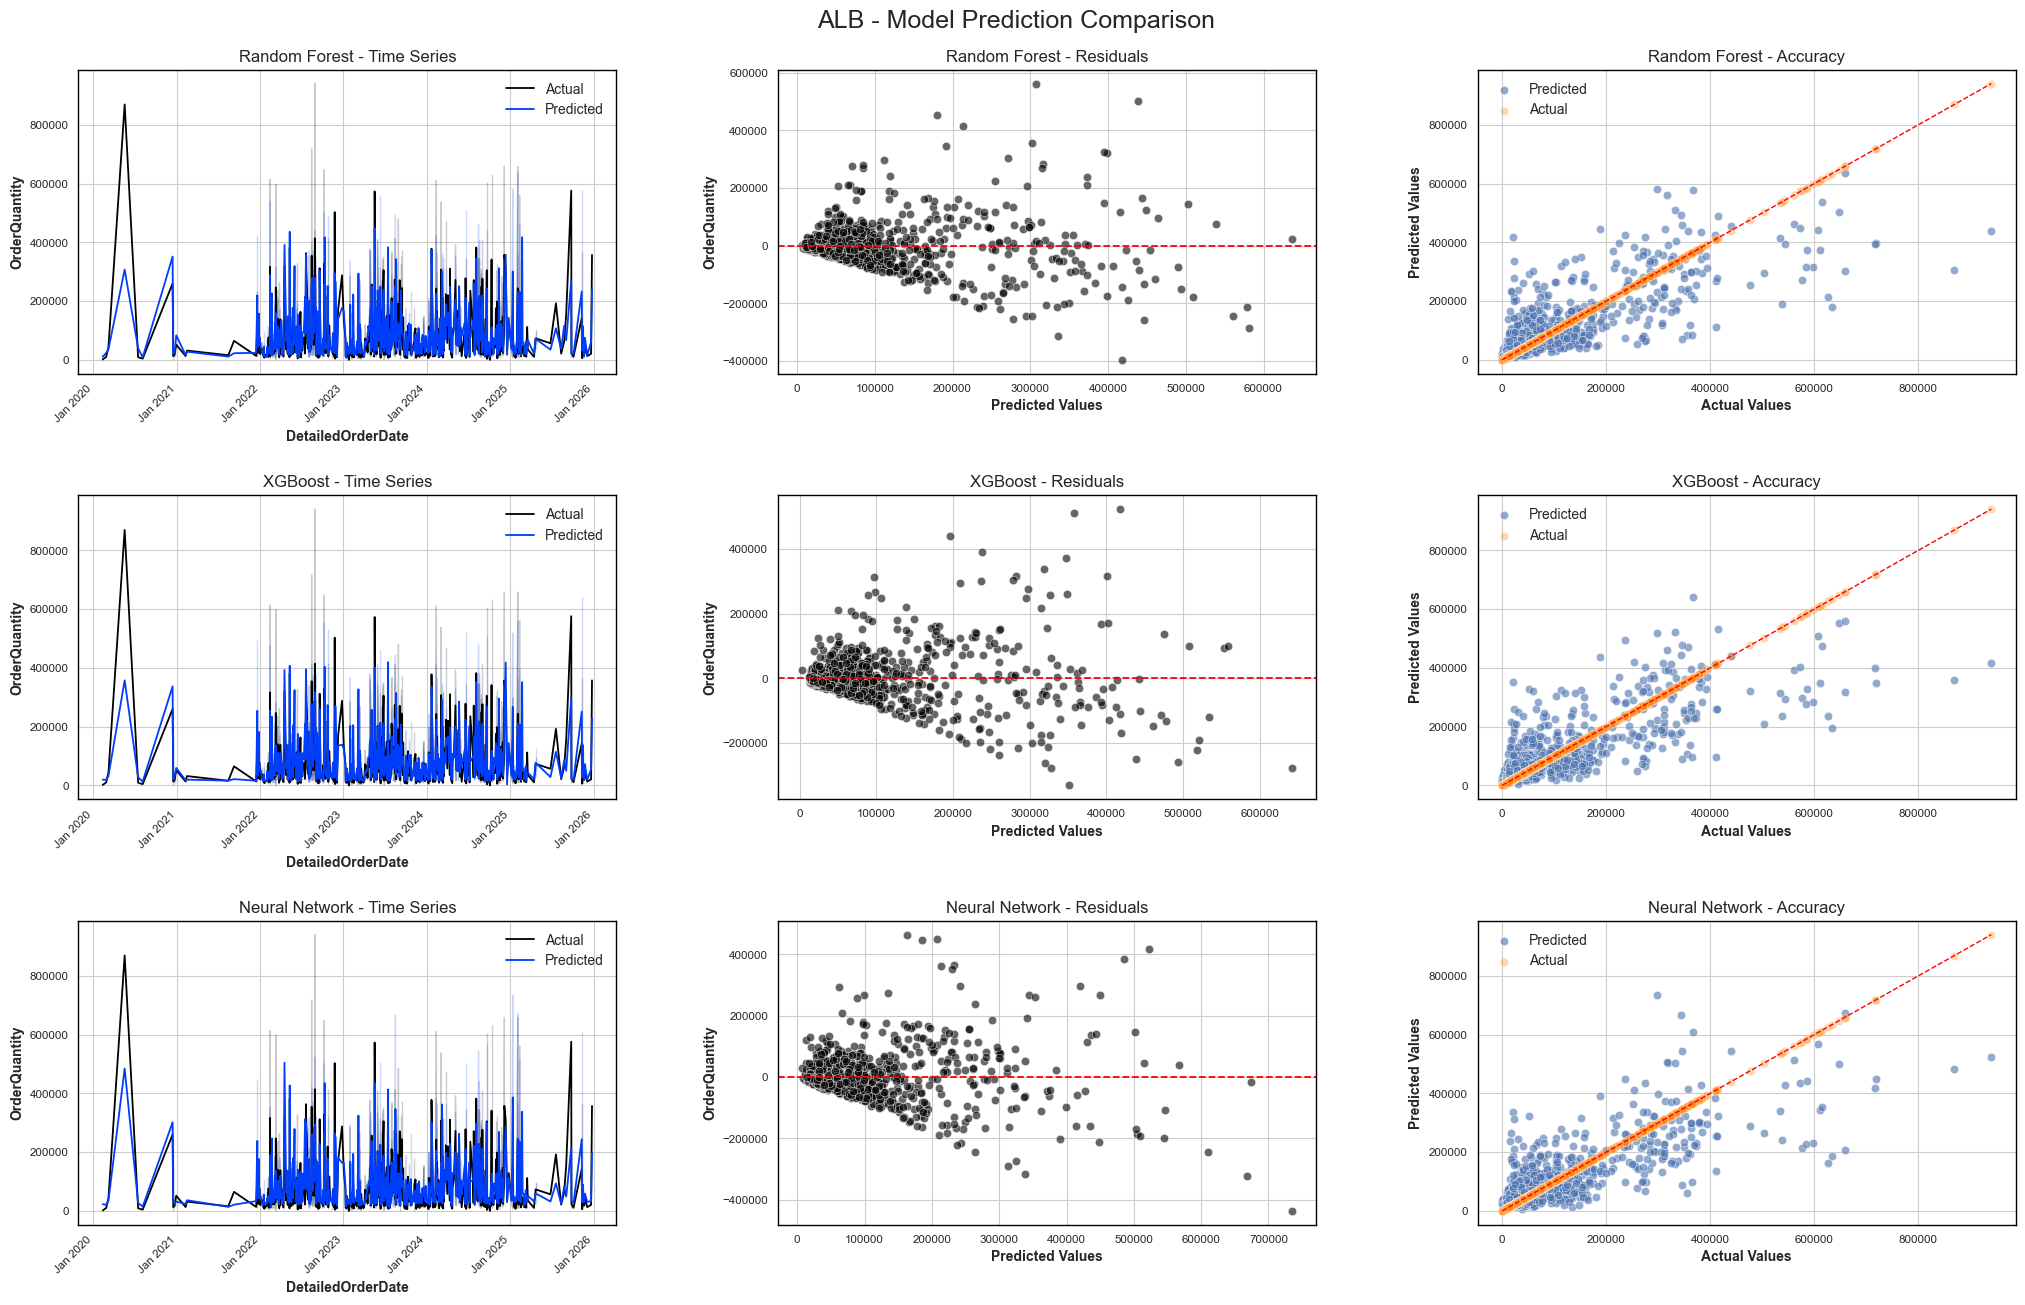

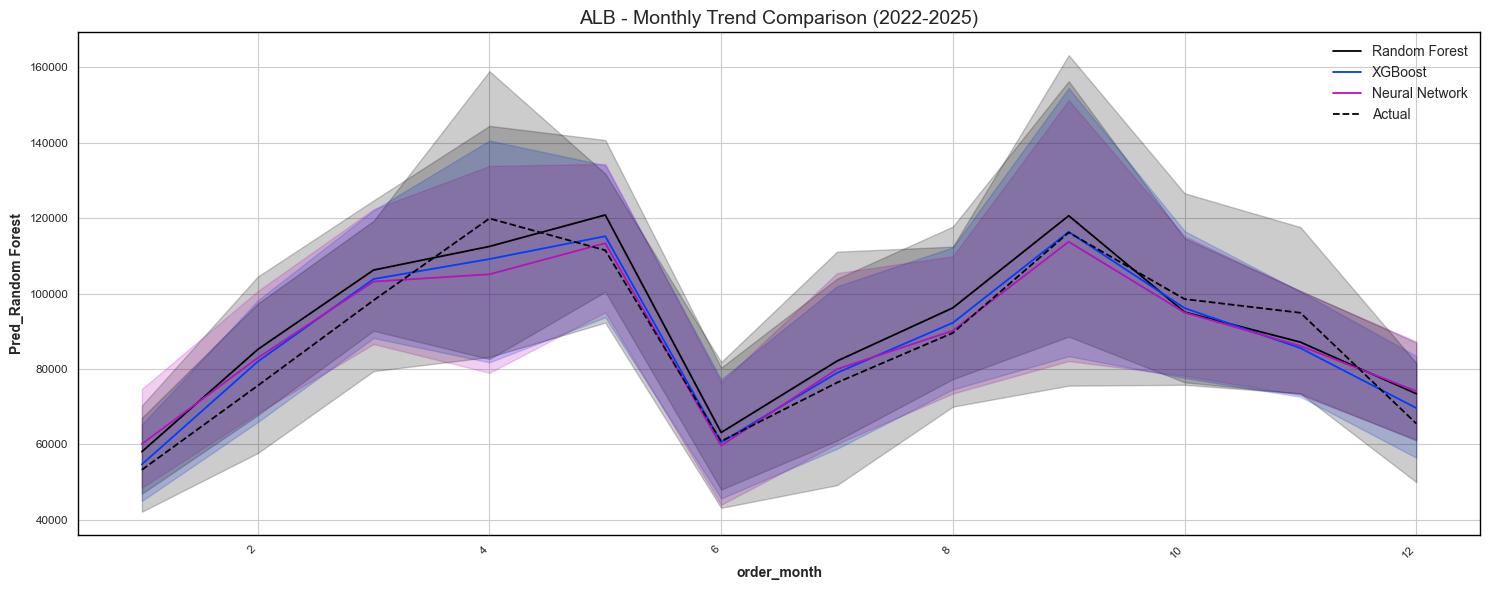

In [ ]:
# Plotting code fix
import matplotlib.dates as mdates
import seaborn as sns

# Set global style for all plots
sns.set_style("whitegrid")  # Adds grids and borders
plt.rcParams['axes.edgecolor'] = 'black'  # Ensure axis borders are visible

plot_dates = customer_total.loc[y_val.index, 'DetailedOrderDate']  # Changed X to df
if not pd.api.types.is_datetime64_any_dtype(plot_dates):
    plot_dates = pd.to_datetime(plot_dates)

# Create main comparison plots
fig, axes = plt.subplots(3, 3, figsize=(25, 15))
fig.suptitle(f"{custom_ref} - Model Prediction Comparison", 
             fontsize=18, y=0.92)
fig.subplots_adjust(hspace=0.4, wspace=0.3)

models = {
    "Random Forest": rf_model.predict(X_val),
    "XGBoost": best_xgb.predict(X_val),
    "Neural Network": mlp.predict(X_val_scaled)
}

for row, (model_name, y_pred) in enumerate(models.items()):
    # Time Series Comparison
    ax = axes[row, 0]
    sns.lineplot(x=plot_dates, y=y_val, label='Actual', color='#4C72B0', ax=ax, linewidth=1.5)
    sns.lineplot(x=plot_dates, y=y_pred, label='Predicted', color='#ff8000', ax=ax, linewidth=1.5)
    ax.set_title(f'{model_name} - Time Series', fontsize=12)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.grid(True, linestyle='--', alpha=0.6)

    # Residual Plot
    ax = axes[row, 1]
    residuals = y_val - y_pred
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=ax, edgecolor='k', linewidth=0.5, color='#4C72B0')
    ax.axhline(0, color='r', linestyle='--', linewidth=1.5)
    ax.set_title(f'{model_name} - Residuals', fontsize=12)
    ax.set_xlabel('Predicted Values')
    ax.grid(True, linestyle='--', alpha=0.6)

    # Actual vs Predicted
    ax = axes[row, 2]
    max_val = max(y_val.max(), y_pred.max())
    
    # Scatter plot with custom colors
    sns.scatterplot(x=y_val, y=y_pred, color='#4C72B0', alpha=0.6, ax=ax, label='Predicted', edgecolor='k', linewidth=0.5)
    sns.scatterplot(x=y_val, y=y_val, color='#ff8000', alpha=0.3, ax=ax, label='Actual', edgecolor='k', linewidth=0.5)  # Perfect line as reference
    
    # 1:1 reference line
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
    
    ax.set_title(f'{model_name} - Accuracy', fontsize=12)
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Monthly trend plot fix
fig2, ax2 = plt.subplots(figsize=(15, 6))
monthly_data = df.loc[y_val.index, ['order_month']].copy()  # Changed X to df
monthly_data['Actual'] = y_val.values

for model_name, y_pred in models.items():
    monthly_data[f'Pred_{model_name}'] = y_pred
    sns.lineplot(x='order_month', y=f'Pred_{model_name}', 
                data=monthly_data, label=model_name, ax=ax2, linewidth=2)

sns.lineplot(x='order_month', y='Actual', data=monthly_data, 
            label='Actual', ax=ax2, color='black', linestyle='--', linewidth=2)
ax2.set_title(f'{custom_ref} - Monthly Trend Comparison (2022-2025)', fontsize=14)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()